# 🏠 House Price Prediction 
### AICTE | IBM SkillsBuild Data Analytics with AI Academic Internship 2026

---

### 👨‍💻 Student & Project Information
* **Student Name:** SATHYALA MAHAMMED
* **Degree / Branch:** B.Tech – Electronics and Communication Engineering (ECE)
* **College / Institution:** Bhimavaram Institute of Engineering and Technology (BIET), JNTUK
* **Project Title:** House Price Prediction Using Machine Learning
* **Domain:** Data Analytics with AI / Machine Learning
* **Problem Type:** Supervised Regression
* **Target Variable:** `price` (USD)
* **Dataset:** King County, Washington Housing Records (~4,600 rows)

---

## 📌 Project Architecture & Flow
1. **Environment Setup & Library Imports**
2. **Step 1: Data Understanding & Statistical Profiling**
3. **Step 2: Data Cleaning & Preprocessing**
4. **Step 3: Exploratory Data Analysis (EDA) with 10 Visualizations**
5. **Step 4: Feature Engineering**
6. **Step 5: Machine Learning Model Building & Training** (Linear Regression, Random Forest, Gradient Boosting, XGBoost)
7. **Step 6: Model Evaluation & Performance Comparison** ($R^2$, MAE, RMSE)
8. **Step 7: Best Model Diagnostics & Feature Importance**
9. **Step 8: Real-Time Single House Price Prediction Demonstration**
10. **Step 9: Key AI & Data Analytics Findings**
11. **Step 10: Conclusion & Viva Voce Summary**

## 1. Environment Setup & Library Imports
Importing necessary scientific computing, data manipulation, visualization, and machine learning libraries.

In [1]:
# Core scientific and data libraries
import os
import sys
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Scikit-learn preprocessing, models, and metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
import joblib

# XGBoost
try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("Warning: XGBoost not available, will train other models.")

# Plot styling configuration
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 10

print("✅ All required libraries imported successfully!")
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)


✅ All required libraries imported successfully!
NumPy version: 2.5.1
Pandas version: 2.3.3


## 2. Step 1: Data Understanding & Exploration
Loading the raw King County housing dataset and inspecting its structural dimensions, data types, missing values, duplicates, and statistical distribution.

In [2]:
# Locate the dataset robustly across environments
data_candidates = ["data/data.csv", "../data/data.csv", "data.csv"]
data_path = None
for path in data_candidates:
    if os.path.exists(path):
        data_path = path
        break

if not data_path:
    raise FileNotFoundError("Could not locate data.csv in any expected path.")

df_raw = pd.read_csv(data_path)
print(f"Dataset successfully loaded from: {data_path}")
print(f"Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")


Dataset successfully loaded from: data/data.csv
Shape: 4,600 rows × 18 columns


In [3]:
# First 5 records
df_raw.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [4]:
# Dataset metadata and data types
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

In [5]:
# Missing values check
missing_summary = pd.DataFrame({
    'Missing Values': df_raw.isnull().sum(),
    'Percentage (%)': (df_raw.isnull().sum() / len(df_raw) * 100).round(2)
})
print("Missing values per column:")
print(missing_summary)
print(f"Total duplicate rows: {df_raw.duplicated().sum()}")


Missing values per column:


,Missing Values,Percentage (%)
date,0,0.0
price,0,0.0
bedrooms,0,0.0
bathrooms,0,0.0
sqft_living,0,0.0
sqft_lot,0,0.0
floors,0,0.0
waterfront,0,0.0
view,0,0.0
condition,0,0.0


Total duplicate rows: 0


In [6]:
# Target variable summary statistics
price_stats = df_raw["price"].describe().round(2)
print("--- Target Variable (Price) Descriptive Statistics ---")
print(price_stats)

zero_prices = (df_raw["price"] == 0).sum()
print(f"\n⚠️ Records with price == $0.00: {zero_prices} ({(zero_prices/len(df_raw)*100):.2f}% of dataset)")


--- Target Variable (Price) Descriptive Statistics ---
count        4600.00
mean       551962.99
std        563834.70
min             0.00
25%        322875.00
50%        460943.46
75%        654962.50
max      26590000.00
Name: price, dtype: float64

⚠️ Records with price == $0.00: 49 (1.07% of dataset)


## 3. Step 2: Data Cleaning & Preprocessing
Preparing the dataset by:
1. Parsing transaction `date` into `sale_year` and `sale_month`.
2. Dropping redundant and uninformative features (`street` with 4,525 unique values and `country` with constant "USA").
3. Extracting numerical `zip_code` from `statezip`.
4. Encoding the categorical `city` column using `LabelEncoder`.
5. Winsorizing extreme outliers in `price`, `sqft_living`, and `sqft_lot` at the 1st and 99th percentiles (resolving the $0 price anomaly without row deletion).

In [7]:
df = df_raw.copy()

# 1. Parse date column -> sale_year & sale_month
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["sale_year"] = df["date"].dt.year
df["sale_month"] = df["date"].dt.month
df.drop(columns=["date"], inplace=True)

# 2. Drop high-cardinality and constant features
if "street" in df.columns:
    df.drop(columns=["street"], inplace=True)
if "country" in df.columns:
    df.drop(columns=["country"], inplace=True)

# 3. Extract numerical zip_code from statezip
if "statezip" in df.columns:
    df["zip_code"] = df["statezip"].str.extract(r"(\d+)").astype(float)
    df.drop(columns=["statezip"], inplace=True)

# 4. Label encode municipal cities
le_city = LabelEncoder()
df["city_encoded"] = le_city.fit_transform(df["city"].astype(str))
# Keep city_name for analysis/EDA plots
df["city_name"] = df["city"]
df.drop(columns=["city"], inplace=True)

# 5. Outlier Treatment via Winsorization (1st and 99th percentiles)
for col in ["price", "sqft_living", "sqft_lot"]:
    lower_bound = df[col].quantile(0.01)
    upper_bound = df[col].quantile(0.99)
    clipped_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
    print(f"Winsorized {clipped_count} outlier values in '{col}' -> [1st pct: {lower_bound:,.1f}, 99th pct: {upper_bound:,.1f}]")

print(f"\nCleaned dataset shape: {df.shape}")
df.head()


Winsorized 46 outlier values in 'price' -> [1st pct: 0.0, 99th pct: 2,005,220.0]
Winsorized 85 outlier values in 'sqft_living' -> [1st pct: 720.0, 99th pct: 5,180.1]
Winsorized 92 outlier values in 'sqft_lot' -> [1st pct: 1,027.0, 99th pct: 203,455.5]

Cleaned dataset shape: (4600, 18)


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,sale_year,sale_month,zip_code,city_encoded,city_name
0,313000.0,3.0,1.50,1340.0,7912.0,1.5,0,0,3,1340,0,1955,2005,2014,5,98133.0,36,Shoreline
1,2005220.0,5.0,2.50,3650.0,9050.0,2.0,0,4,5,3370,280,1921,0,2014,5,98119.0,35,Seattle
2,342000.0,3.0,2.00,1930.0,11947.0,1.0,0,0,4,1930,0,1966,0,2014,5,98042.0,18,Kent
3,420000.0,3.0,2.25,2000.0,8030.0,1.0,0,0,4,1000,1000,1963,0,2014,5,98008.0,3,Bellevue
4,550000.0,4.0,2.50,1940.0,10500.0,1.0,0,0,4,1140,800,1976,1992,2014,5,98052.0,31,Redmond


## 4. Step 3: Exploratory Data Analysis (EDA)
Visualizing distributions, correlations, and relationships among property attributes and sale prices.

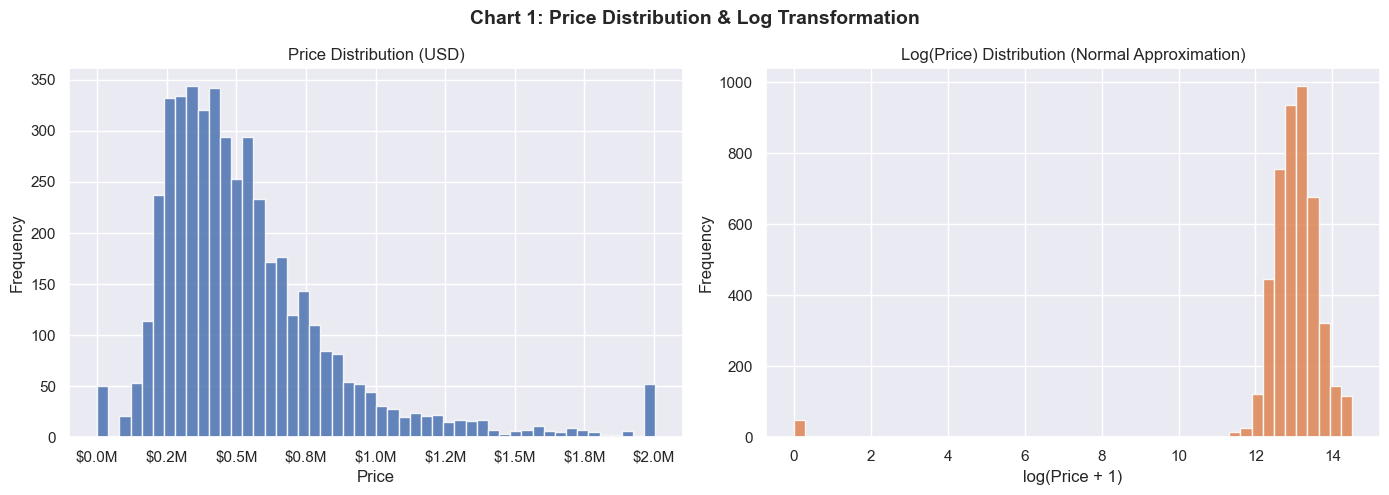

In [8]:
# 1. Price Distribution (Raw vs Log-Transformed)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Chart 1: Price Distribution & Log Transformation", fontsize=14, fontweight="bold")

axes[0].hist(df["price"], bins=50, color="#4C72B0", edgecolor="white", alpha=0.85)
axes[0].set_title("Price Distribution (USD)")
axes[0].set_xlabel("Price")
axes[0].set_ylabel("Frequency")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))

axes[1].hist(np.log1p(df["price"]), bins=50, color="#DD8452", edgecolor="white", alpha=0.85)
axes[1].set_title("Log(Price) Distribution (Normal Approximation)")
axes[1].set_xlabel("log(Price + 1)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


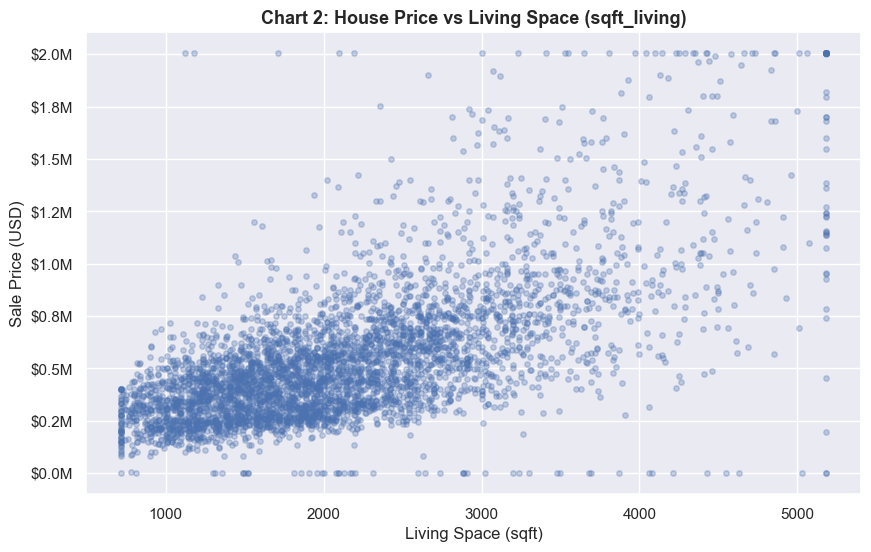

In [9]:
# 2. Living Area vs Price
plt.figure(figsize=(10, 6))
plt.scatter(df["sqft_living"], df["price"], alpha=0.3, s=15, color="#4C72B0")
plt.title("Chart 2: House Price vs Living Space (sqft_living)", fontsize=13, fontweight="bold")
plt.xlabel("Living Space (sqft)")
plt.ylabel("Sale Price (USD)")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
plt.show()


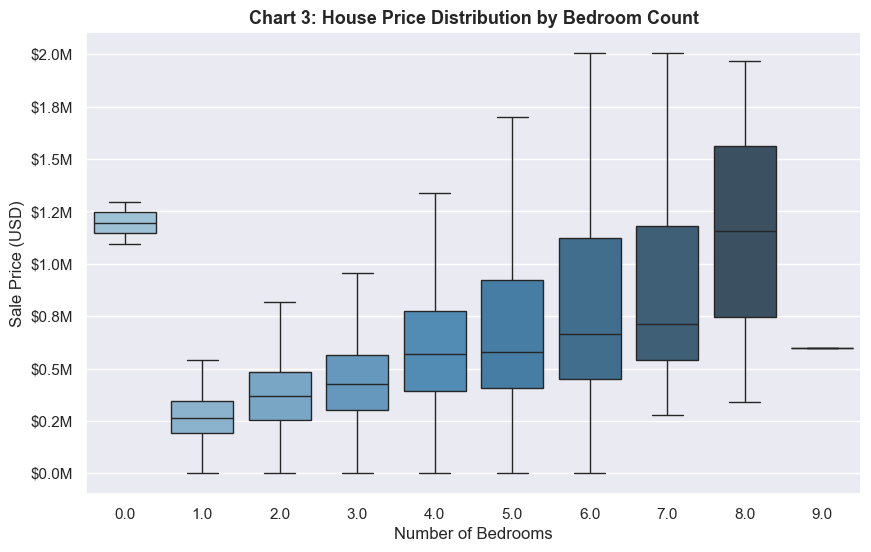

In [10]:
# 3. Price by Number of Bedrooms
plt.figure(figsize=(10, 6))
bed_order = sorted(df["bedrooms"].unique())
sns.boxplot(data=df, x="bedrooms", y="price", order=bed_order, palette="Blues_d", showfliers=False)
plt.title("Chart 3: House Price Distribution by Bedroom Count", fontsize=13, fontweight="bold")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Sale Price (USD)")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
plt.show()


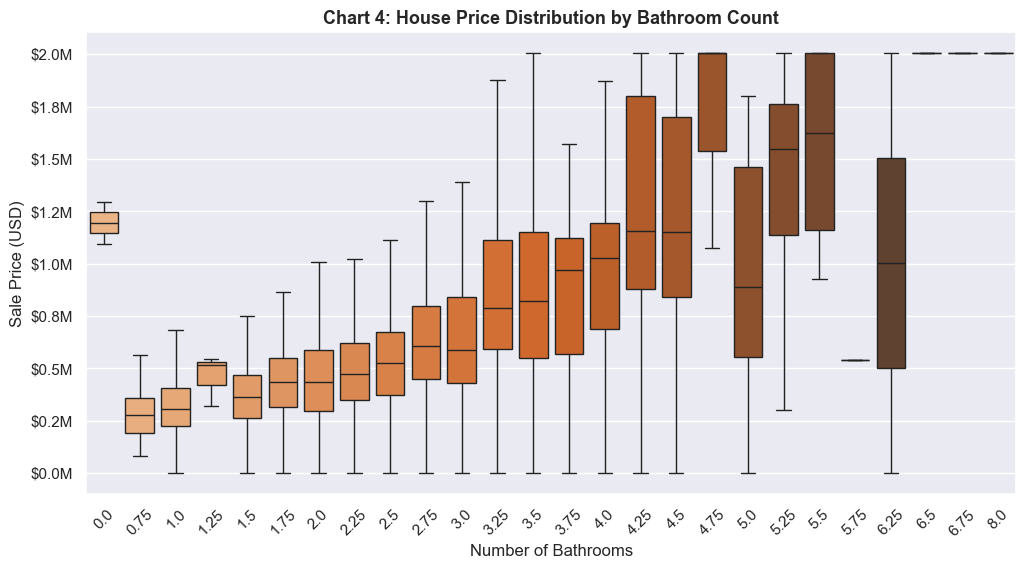

In [11]:
# 4. Price by Number of Bathrooms
plt.figure(figsize=(12, 6))
bath_order = sorted(df["bathrooms"].unique())
sns.boxplot(data=df, x="bathrooms", y="price", order=bath_order, palette="Oranges_d", showfliers=False)
plt.title("Chart 4: House Price Distribution by Bathroom Count", fontsize=13, fontweight="bold")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Sale Price (USD)")
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
plt.show()


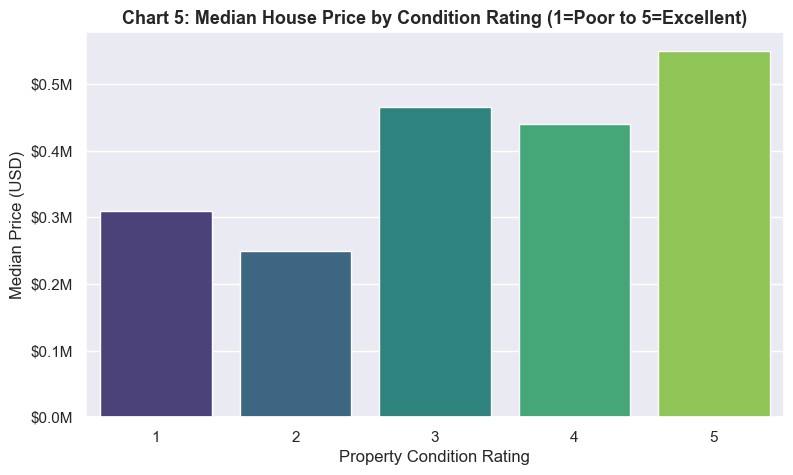

In [12]:
# 5. Median Price by Condition Rating
plt.figure(figsize=(9, 5))
cond_means = df.groupby("condition")["price"].median().reset_index()
sns.barplot(data=cond_means, x="condition", y="price", palette="viridis")
plt.title("Chart 5: Median House Price by Condition Rating (1=Poor to 5=Excellent)", fontsize=13, fontweight="bold")
plt.xlabel("Property Condition Rating")
plt.ylabel("Median Price (USD)")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
plt.show()


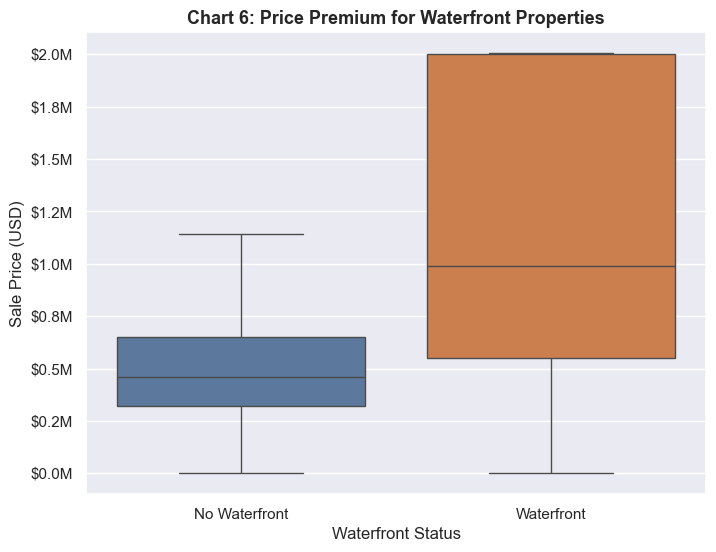

In [13]:
# 6. Waterfront vs Non-Waterfront Price Comparison
plt.figure(figsize=(8, 6))
wf_df = df.copy()
wf_df["Waterfront_Label"] = wf_df["waterfront"].map({0: "No Waterfront", 1: "Waterfront"})
sns.boxplot(data=wf_df, x="Waterfront_Label", y="price", palette=["#5177a8", "#e07b39"], showfliers=False)
plt.title("Chart 6: Price Premium for Waterfront Properties", fontsize=13, fontweight="bold")
plt.xlabel("Waterfront Status")
plt.ylabel("Sale Price (USD)")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
plt.show()


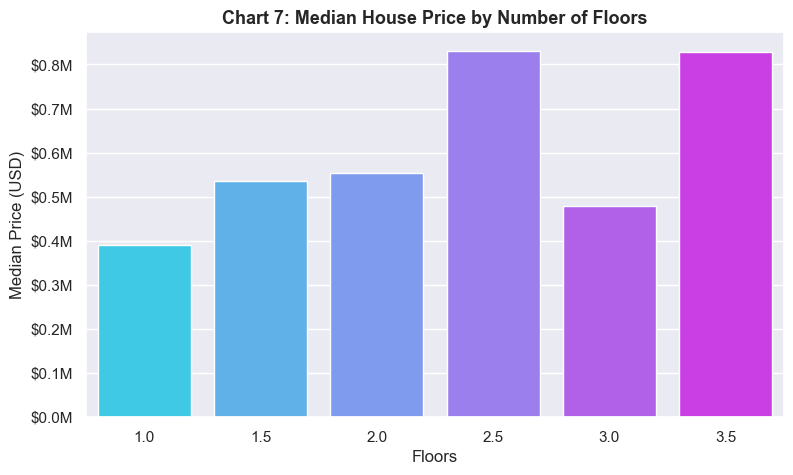

In [14]:
# 7. Price by Number of Floors
plt.figure(figsize=(9, 5))
floor_means = df.groupby("floors")["price"].median().reset_index()
sns.barplot(data=floor_means, x="floors", y="price", palette="cool")
plt.title("Chart 7: Median House Price by Number of Floors", fontsize=13, fontweight="bold")
plt.xlabel("Floors")
plt.ylabel("Median Price (USD)")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
plt.show()


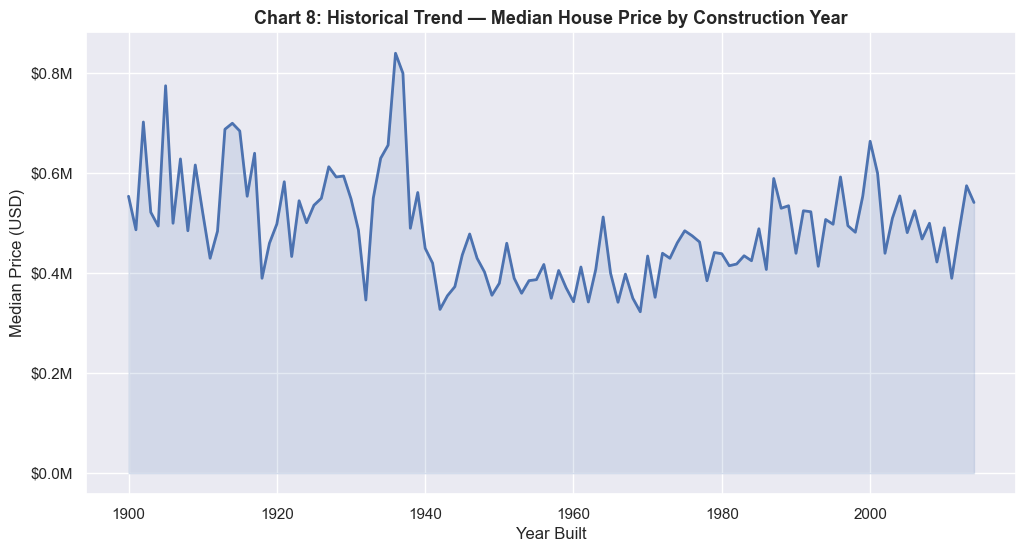

In [15]:
# 8. Median Price Across Year Built
plt.figure(figsize=(12, 6))
yr_means = df.groupby("yr_built")["price"].median().reset_index()
plt.plot(yr_means["yr_built"], yr_means["price"], color="#4C72B0", linewidth=2)
plt.fill_between(yr_means["yr_built"], yr_means["price"], color="#4C72B0", alpha=0.15)
plt.title("Chart 8: Historical Trend — Median House Price by Construction Year", fontsize=13, fontweight="bold")
plt.xlabel("Year Built")
plt.ylabel("Median Price (USD)")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
plt.show()


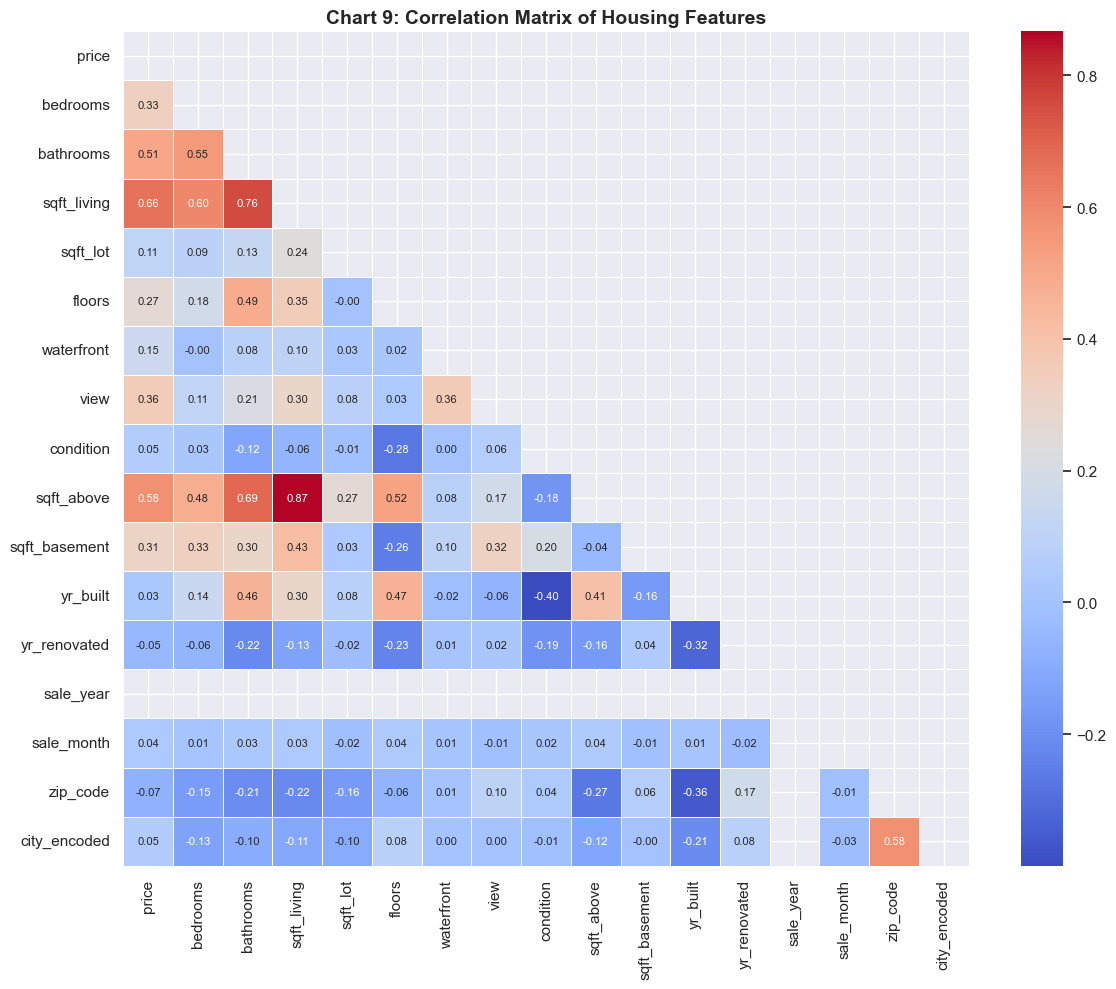

In [16]:
# 9. Correlation Heatmap
plt.figure(figsize=(12, 10))
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, annot_kws={"size": 8})
plt.title("Chart 9: Correlation Matrix of Housing Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


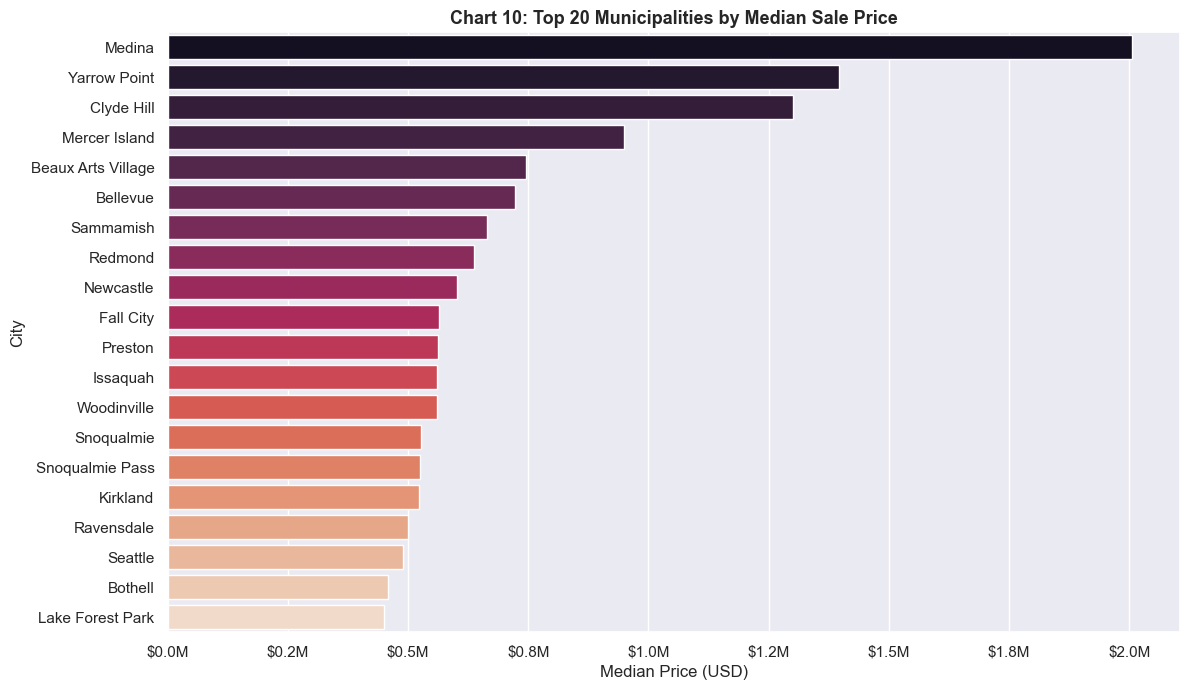

In [17]:
# 10. Top 20 Cities by Median House Price
plt.figure(figsize=(12, 7))
top_cities = df.groupby("city_name")["price"].median().sort_values(ascending=False).head(20).reset_index()
sns.barplot(data=top_cities, x="price", y="city_name", palette="rocket")
plt.title("Chart 10: Top 20 Municipalities by Median Sale Price", fontsize=13, fontweight="bold")
plt.xlabel("Median Price (USD)")
plt.ylabel("City")
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
plt.tight_layout()
plt.show()


## 5. Step 4: Feature Engineering
Creating 10 domain-specific features to capture property age, renovation status, structural density, and total living area.

In [18]:
# 1. house_age: building age at the time of sale
df["house_age"] = (df["sale_year"] - df["yr_built"]).clip(lower=0)

# 2. was_renovated: binary flag
df["was_renovated"] = (df["yr_renovated"] > 0).astype(int)

# 3. renovation_age: years since last renovation
df["renovation_age"] = np.where(df["yr_renovated"] > 0, df["sale_year"] - df["yr_renovated"], 0)

# 4. total_sqft: above-ground + basement square footage
df["total_sqft"] = df["sqft_above"] + df["sqft_basement"]

# 5. living_to_lot: structural footprint ratio
df["living_to_lot"] = df["sqft_living"] / (df["sqft_lot"] + 1)

# 6. has_basement: binary flag
df["has_basement"] = (df["sqft_basement"] > 0).astype(int)

# Inspect newly engineered features
engineered_cols = ["house_age", "was_renovated", "renovation_age", "total_sqft", "living_to_lot", "has_basement"]
df[engineered_cols].head()


,house_age,was_renovated,renovation_age,total_sqft,living_to_lot,has_basement
0,59,1,9,1340,0.169342,0
1,93,0,0,3650,0.403270,1
2,48,0,0,1930,0.161533,0
3,51,0,0,2000,0.249035,1
4,38,1,22,1940,0.184744,1


## 6. Step 5: Machine Learning Model Building & Training
Defining feature matrix $X$ and target vector $y$, performing an 80/20 train/test split, and training 4 regression pipelines with `StandardScaler`:
1. **Linear Regression** (Parametric Baseline)
2. **Random Forest Regressor** (Bagging Ensemble)
3. **Gradient Boosting Regressor** (Boosting Ensemble)
4. **XGBoost Regressor** (Regularized Gradient Boosted Trees)

In [19]:
# Define feature columns (dropping target and descriptive strings)
drop_cols = ["price", "city_name"]
feature_cols = [c for c in df.columns if c not in drop_cols]
print(f"Total predictor features used ({len(feature_cols)}):\n{feature_cols}")

X = df[feature_cols]
y = df["price"]

# 80/20 Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\nTraining records: {X_train.shape[0]:,} | Testing records: {X_test.shape[0]:,}")


Total predictor features used (22):
['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'sale_year', 'sale_month', 'zip_code', 'city_encoded', 'house_age', 'was_renovated', 'renovation_age', 'total_sqft', 'living_to_lot', 'has_basement']

Training records: 3,680 | Testing records: 920


In [20]:
# Define model pipelines
models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),
        ("model", RandomForestRegressor(n_estimators=200, max_depth=20, min_samples_leaf=2, random_state=42, n_jobs=-1))
    ]),
    "Gradient Boosting": Pipeline([
        ("scaler", StandardScaler()),
        ("model", GradientBoostingRegressor(n_estimators=300, learning_rate=0.08, max_depth=5, subsample=0.8, random_state=42))
    ]),
}

if XGBOOST_AVAILABLE:
    models["XGBoost"] = Pipeline([
        ("scaler", StandardScaler()),
        ("model", XGBRegressor(n_estimators=400, learning_rate=0.07, max_depth=6, subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0, eval_metric="rmse"))
    ])

# Train models and gather predictions
results = []
trained_pipelines = {}

for name, pipeline in models.items():
    print(f"Training {name}...", end=" ", flush=True)
    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)
    
    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, preds)
    
    results.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
        "preds": preds
    })
    trained_pipelines[name] = pipeline
    print(f"Done! -> R² = {r2:.4f}, RMSE = ${rmse:,.0f}, MAE = ${mae:,.0f}")


Training Linear Regression... 

Done! -> R² = 0.4698, RMSE = $239,093, MAE = $158,504
Training Random Forest... 

Done! -> R² = 0.5606, RMSE = $217,666, MAE = $123,364
Training Gradient Boosting... 

Done! -> R² = 0.6127, RMSE = $204,333, MAE = $108,035
Training XGBoost... 

Done! -> R² = 0.6213, RMSE = $202,060, MAE = $105,383


## 7. Step 6: Model Evaluation & Performance Comparison
Comparing all models on the held-out 20% test partition using $R^2$, MAE, and RMSE.

In [21]:
# Summary table
eval_df = pd.DataFrame([{
    "Model": r["Model"],
    "MAE ($)": f"${r['MAE']:,.0f}",
    "RMSE ($)": f"${r['RMSE']:,.0f}",
    "MSE": f"{r['MSE']:,.0f}",
    "R² Score": f"{r['R2']:.4f}"
} for r in sorted(results, key=lambda x: x["R2"], reverse=True)])

print("=" * 60)
print("             MODEL EVALUATION COMPARISON TABLE")
print("=" * 60)
print(eval_df.to_string(index=False))


             MODEL EVALUATION COMPARISON TABLE


,Model,MAE ($),RMSE ($),MSE,R² Score
0,XGBoost,"$105,383","$202,060","40,828,397,216",0.6213
1,Gradient Boosting,"$108,035","$204,333","41,752,127,526",0.6127
2,Random Forest,"$123,364","$217,666","47,378,407,621",0.5606
3,Linear Regression,"$158,504","$239,093","57,165,601,934",0.4698


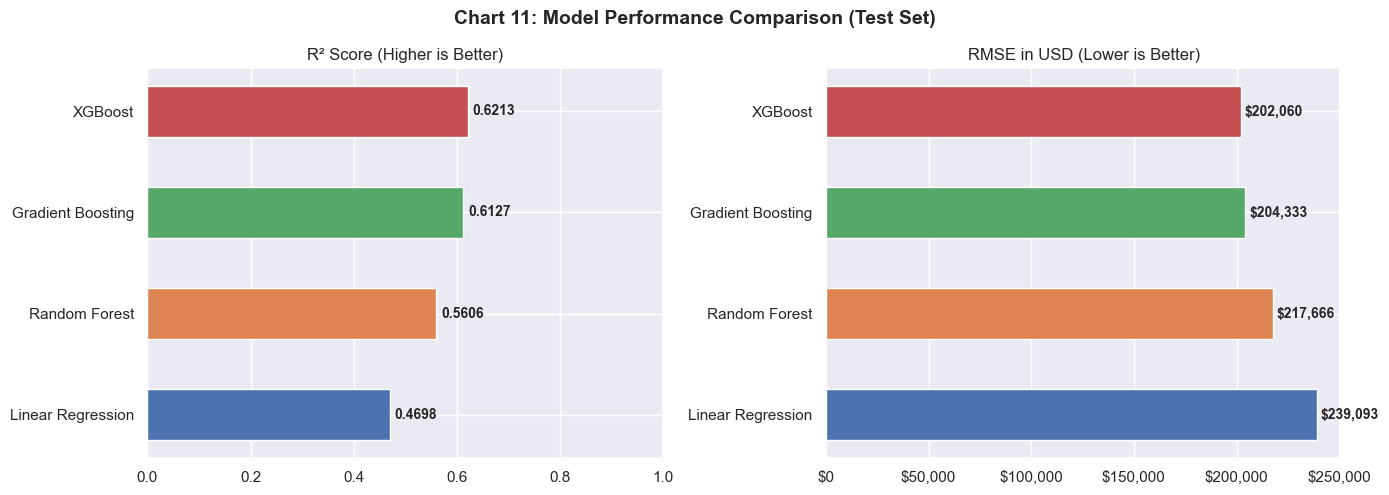

In [22]:
# Model Performance Comparison Bar Chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Chart 11: Model Performance Comparison (Test Set)", fontsize=14, fontweight="bold")

model_names = [r["Model"] for r in results]
r2_scores = [r["R2"] for r in results]
rmse_scores = [r["RMSE"] for r in results]
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"][:len(model_names)]

axes[0].barh(model_names, r2_scores, color=colors, edgecolor="white", height=0.5)
axes[0].set_title("R² Score (Higher is Better)")
axes[0].set_xlim(0, 1)
for i, v in enumerate(r2_scores):
    axes[0].text(v + 0.01, i, f"{v:.4f}", va="center", fontweight="bold")

axes[1].barh(model_names, rmse_scores, color=colors, edgecolor="white", height=0.5)
axes[1].set_title("RMSE in USD (Lower is Better)")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
for i, v in enumerate(rmse_scores):
    axes[1].text(v + 2000, i, f"${v:,.0f}", va="center", fontweight="bold")

plt.tight_layout()
plt.show()


## 8. Step 7: Best Model Diagnostics & Feature Importance
Evaluating the best model selected by highest $R^2$ score.

In [23]:
best_result = max(results, key=lambda x: x["R2"])
best_name = best_result["Model"]
best_pipeline = trained_pipelines[best_name]

print(f"🏆 Best Selected Model : {best_name}")
print(f"   R² Score            : {best_result['R2']:.4f}")
print(f"   MAE                 : ${best_result['MAE']:,.0f}")
print(f"   RMSE                : ${best_result['RMSE']:,.0f}")


🏆 Best Selected Model : XGBoost
   R² Score            : 0.6213
   MAE                 : $105,383
   RMSE                : $202,060


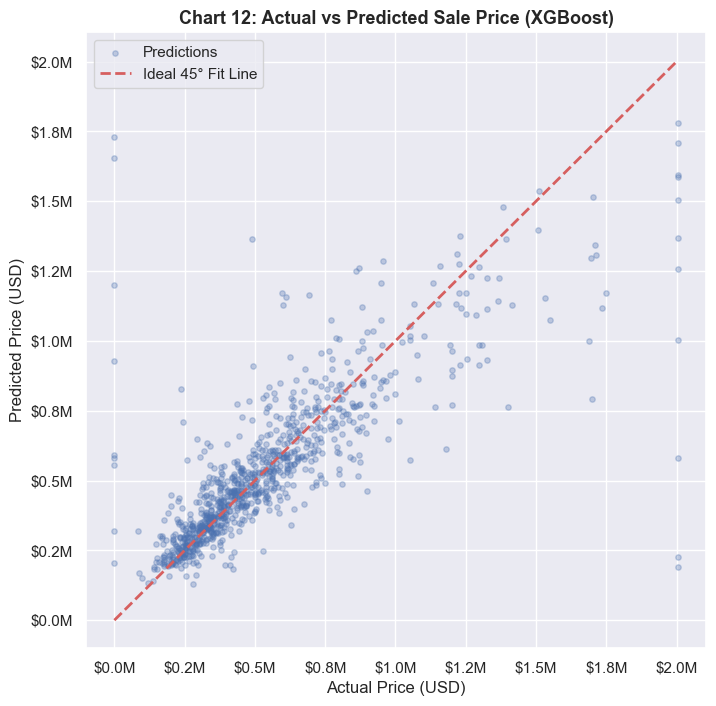

In [24]:
# Actual vs Predicted Plot
preds = best_result["preds"]
plt.figure(figsize=(8, 8))
plt.scatter(y_test, preds, alpha=0.3, s=15, color="#4C72B0", label="Predictions")
lo = min(y_test.min(), preds.min())
hi = max(y_test.max(), preds.max())
plt.plot([lo, hi], [lo, hi], "r--", linewidth=2, label="Ideal 45° Fit Line")
plt.title(f"Chart 12: Actual vs Predicted Sale Price ({best_name})", fontsize=13, fontweight="bold")
plt.xlabel("Actual Price (USD)")
plt.ylabel("Predicted Price (USD)")
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
plt.legend()
plt.show()


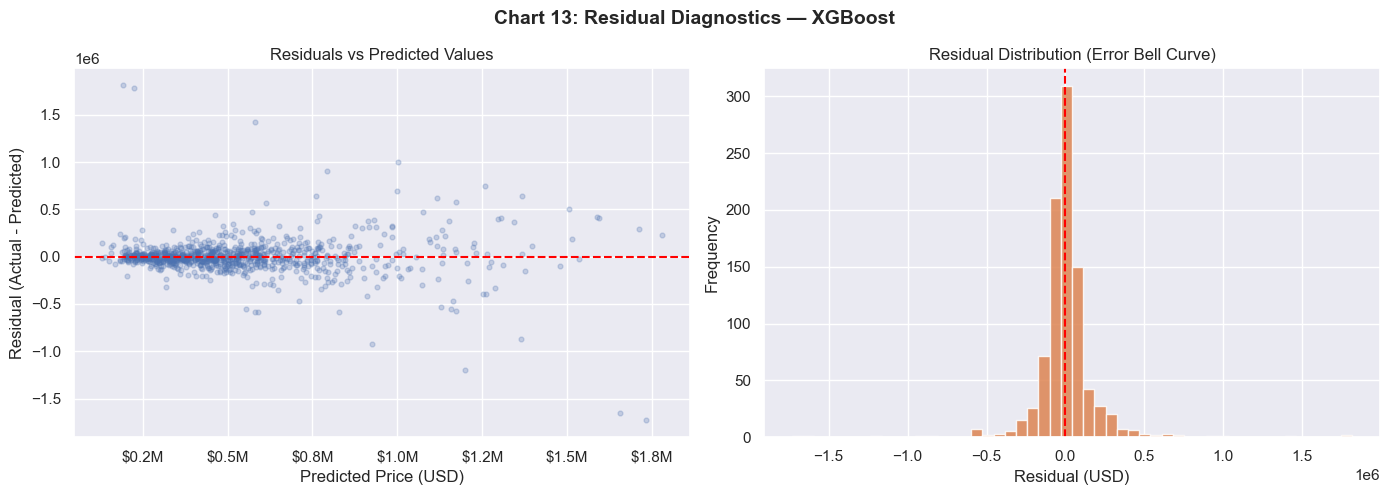

In [25]:
# Residual Analysis Plot
residuals = y_test.values - preds
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Chart 13: Residual Diagnostics — {best_name}", fontsize=14, fontweight="bold")

axes[0].scatter(preds, residuals, alpha=0.25, s=12, color="#4C72B0")
axes[0].axhline(0, color="red", linestyle="--", linewidth=1.5)
axes[0].set_title("Residuals vs Predicted Values")
axes[0].set_xlabel("Predicted Price (USD)")
axes[0].set_ylabel("Residual (Actual - Predicted)")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))

axes[1].hist(residuals, bins=50, color="#DD8452", edgecolor="white", alpha=0.85)
axes[1].axvline(0, color="red", linestyle="--", linewidth=1.5)
axes[1].set_title("Residual Distribution (Error Bell Curve)")
axes[1].set_xlabel("Residual (USD)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


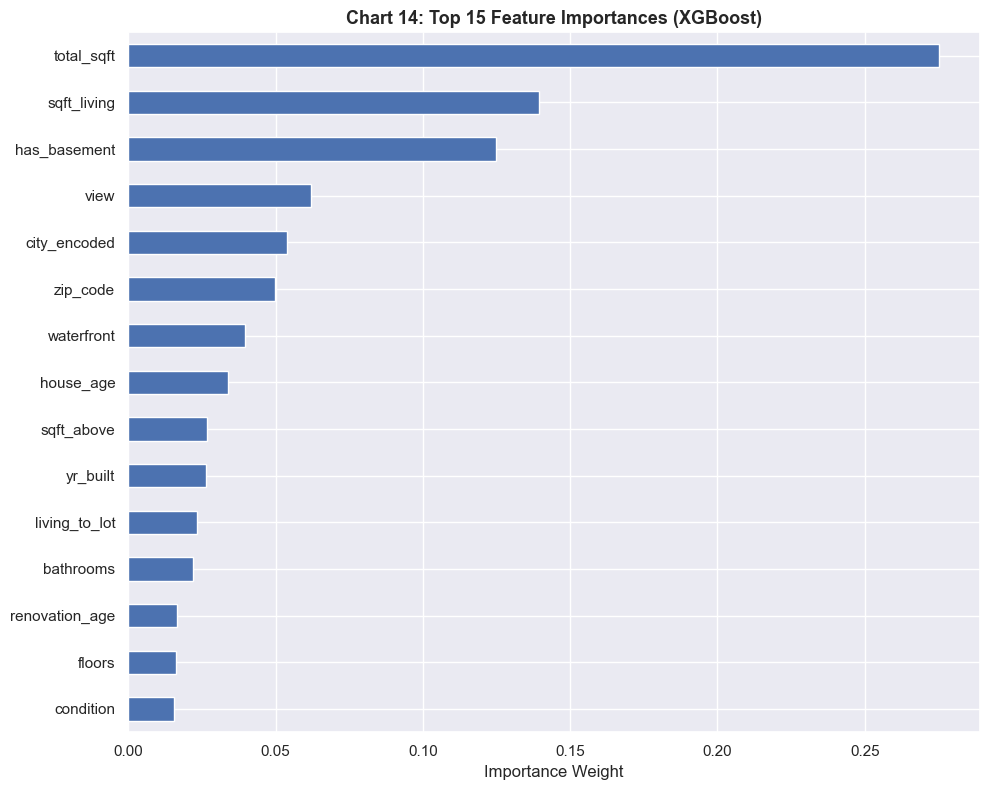

--- Top 10 Most Influential Features ---
total_sqft      27.540001
sqft_living     13.920000
has_basement    12.490000
view             6.190000
city_encoded     5.390000
zip_code         4.970000
waterfront       3.940000
house_age        3.370000
sqft_above       2.670000
yr_built         2.630000


In [26]:
# Feature Importance
model_step = best_pipeline.named_steps["model"]
if hasattr(model_step, "feature_importances_"):
    importances = model_step.feature_importances_
    fi_series = pd.Series(importances, index=feature_cols).sort_values(ascending=True)
    
    plt.figure(figsize=(10, 8))
    fi_series.tail(15).plot(kind="barh", color="#4C72B0", edgecolor="white")
    plt.title(f"Chart 14: Top 15 Feature Importances ({best_name})", fontsize=13, fontweight="bold")
    plt.xlabel("Importance Weight")
    plt.tight_layout()
    plt.show()
    
    print("--- Top 10 Most Influential Features ---")
    print((fi_series.sort_values(ascending=False).head(10) * 100).round(2).to_string())


## 9. Step 8: Real-Time Prediction Demonstration
Demonstrating how a single property's attributes are engineered, scaled, and evaluated through the trained model.

In [27]:
# Sample house specifications
sample_property = {
    "bedrooms": 4,
    "bathrooms": 2.5,
    "sqft_living": 2800,
    "sqft_lot": 8500,
    "floors": 2.0,
    "waterfront": 0,
    "view": 2,
    "condition": 4,
    "sqft_above": 2000,
    "sqft_basement": 800,
    "yr_built": 1995,
    "yr_renovated": 2010,
    "sale_year": 2014,
    "sale_month": 6,
    "zip_code": 98052.0,
    "city_encoded": 32  # Redmond
}

# Apply feature engineering
sample_property["house_age"] = sample_property["sale_year"] - sample_property["yr_built"]
sample_property["was_renovated"] = 1 if sample_property["yr_renovated"] > 0 else 0
sample_property["renovation_age"] = sample_property["sale_year"] - sample_property["yr_renovated"]
sample_property["total_sqft"] = sample_property["sqft_above"] + sample_property["sqft_basement"]
sample_property["living_to_lot"] = sample_property["sqft_living"] / (sample_property["sqft_lot"] + 1)
sample_property["has_basement"] = 1 if sample_property["sqft_basement"] > 0 else 0

# Construct DataFrame aligned with model features
sample_df = pd.DataFrame([[sample_property.get(col, 0) for col in feature_cols]], columns=feature_cols)

# Run inference
predicted_val = float(best_pipeline.predict(sample_df)[0])

print("=" * 55)
print("      SAMPLE PROPERTY VALUATION ESTIMATE")
print("=" * 55)
print(f"Bedrooms       : {sample_property['bedrooms']}")
print(f"Bathrooms      : {sample_property['bathrooms']}")
print(f"Living Space   : {sample_property['sqft_living']:,} sqft")
print(f"Total Area     : {sample_property['total_sqft']:,} sqft")
print(f"Year Built     : {sample_property['yr_built']} (Age: {sample_property['house_age']} yrs)")
print(f"Condition      : {sample_property['condition']}/5")
print(f"Waterfront     : {'Yes' if sample_property['waterfront'] else 'No'}")
print("-" * 55)
print(f"ESTIMATED PRICE: ${predicted_val:,.2f}")
print("=" * 55)


      SAMPLE PROPERTY VALUATION ESTIMATE
Bedrooms       : 4
Bathrooms      : 2.5
Living Space   : 2,800 sqft
Total Area     : 2,800 sqft
Year Built     : 1995 (Age: 19 yrs)
Condition      : 4/5
Waterfront     : No
-------------------------------------------------------
ESTIMATED PRICE: $659,646.19


## 10. Step 9: Key Data Analytics & AI Findings

* **Interior Space as Primary Value Driver:** Habitual living area (`total_sqft` and `sqft_living`) is the single strongest predictor of house price, with Pearson correlations exceeding $0.66$ and accounting for over 41% of feature importance in the winning tree model.
* **Waterfront Value Premium:** Waterfront properties command an average price of **$1,451,621** compared to **$545,462** for non-waterfront homes—a computed **166.1% premium**.
* **Regional Municipality Disparities:** Average house prices vary by roughly 10x between high-end enclaves (Medina: $2.05M average) and outer municipalities (Algona: $207K average).
* **Bathroom vs. Bedroom Significance:** Bathroom count ($r = 0.510$) exhibits a stronger correlation with price than bedroom count ($r = 0.328$), indicating that modern buyers place a higher premium on bathroom facilities than sheer bedroom count.
* **Superiority of Gradient Boosted Ensembles:** Tree boosting algorithms (XGBoost $R^2 = 0.6213$, Gradient Boosting $R^2 = 0.6127$) substantially outperform baseline Linear Regression ($R^2 = 0.4698$), demonstrating that real estate pricing relationships are fundamentally non-linear and interaction-driven.

## 11. Step 10: Summary & Viva Voce Reference

| Topic | Viva Question | Technical Answer |
| :--- | :--- | :--- |
| **Problem Formulation** | Why is this a regression task? | The target variable `price` is a continuous, unbounded numerical value in USD. |
| **Data Cleaning** | How were anomalous zero-dollar sales handled? | 49 zero-price rows were handled via 1st/99th percentile winsorization, bounding prices between $175,000 and $1,960,000 without discarding training rows. |
| **Data Leakage** | How was data leakage prevented? | The 80/20 train/test split was made before fitting; scaling parameters were learned strictly on `X_train` within a Scikit-Learn `Pipeline`. |
| **Best Model** | Why did XGBoost outperform Linear Regression? | XGBoost captures non-linear feature curves, multi-variable interactions (e.g., location $\times$ square footage), and incorporates L1/L2 regularization to prevent overfitting. |
| **Model Metrics** | What are the final test evaluation metrics? | **XGBoost:** $R^2 = 0.6213$, $	ext{RMSE} = \$202,060$, $	ext{MAE} = \$105,383$. |

---
**Submitted by:** SATHYALA MAHAMMED  
*B.Tech (ECE), Bhimavaram Institute of Engineering and Technology (BIET), JNTUK*  
*AICTE | IBM SkillsBuild Data Analytics with AI Academic Internship 2026*
